# BÀI TẬP 3 - ANN: Nhận dạng Cat vs Dog
**Dataset:** TensorFlow Datasets - cats_vs_dogs (public)
**Labels:** 0 = Cat, 1 = Dog
> Dùng `tensorflow_datasets` để tải dataset public, không cần file từ giảng viên.

In [1]:
# ==============================================================
# BƯỚC 1: NẠP THƯ VIỆN
# ==============================================================
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


In [2]:
# ==============================================================
# BƯỚC 2: TẢI VÀ XỬ LÝ DỮ LIỆU CATS VS DOGS
# ==============================================================
IMG_SIZE = (64, 64)  # resize về 64x64 cho ANN
BATCH = 5000

# Tải dataset
ds_train = tfds.load('cats_vs_dogs', split='train[:80%]', as_supervised=True)
ds_test  = tfds.load('cats_vs_dogs', split='train[80%:]', as_supervised=True)

def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.reshape(image, [-1])  # flatten -> 64*64*3 = 12288
    return image, label

ds_train = ds_train.map(preprocess).batch(BATCH).prefetch(tf.data.AUTOTUNE)
ds_test  = ds_test.map(preprocess).batch(BATCH).prefetch(tf.data.AUTOTUNE)

# Lấy toàn bộ vào numpy array
X_train_list, y_train_list = [], []
for X, y in ds_train:
    X_train_list.append(X.numpy())
    y_train_list.append(y.numpy())
X_train = np.concatenate(X_train_list)
y_train = np.concatenate(y_train_list)

X_test_list, y_test_list = [], []
for X, y in ds_test:
    X_test_list.append(X.numpy())
    y_test_list.append(y.numpy())
X_test = np.concatenate(X_test_list)
y_test = np.concatenate(y_test_list)

print('X_train:', X_train.shape, '| y_train:', y_train.shape)
print('X_test:', X_test.shape,  '| y_test:', y_test.shape)
print('Input dim:', X_train.shape[1])

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.H953VW_4.0.1/cats_vs_dogs-train.tfrecord-[0-9][0-9…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
X_train: (18610, 12288) | y_train: (18610,)
X_test: (4652, 12288) | y_test: (4652,)
Input dim: 12288


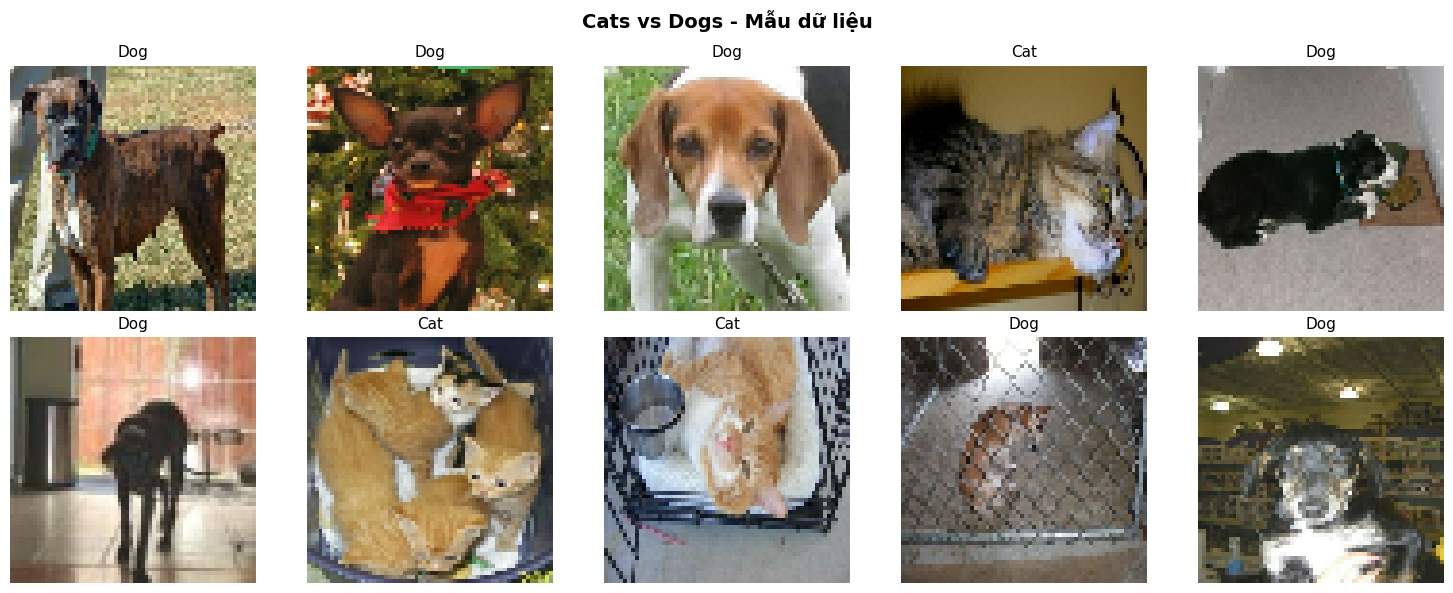

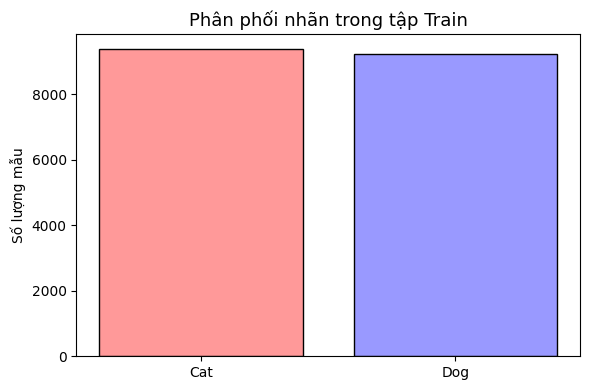

In [3]:
# ==============================================================
# BƯỚC 3: TRỰC QUAN HÓA DỮ LIỆU
# ==============================================================
class_names = ['Cat', 'Dog']

# Lấy lại ảnh gốc (chưa flatten) để hiển thị
ds_show = tfds.load('cats_vs_dogs', split='train[:10]', as_supervised=True)
sample_imgs, sample_labels = [], []
for img, lbl in ds_show:
    sample_imgs.append(tf.image.resize(img, IMG_SIZE).numpy().astype('uint8'))
    sample_labels.append(lbl.numpy())

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()
for i in range(10):
    axes[i].imshow(sample_imgs[i])
    axes[i].set_title(f'{class_names[sample_labels[i]]}', fontsize=11)
    axes[i].axis('off')
plt.suptitle('Cats vs Dogs - Mẫu dữ liệu', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Phân phối nhãn
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(6, 4))
plt.bar([class_names[i] for i in unique], counts, color=['#FF9999','#9999FF'], edgecolor='black')
plt.title('Phân phối nhãn trong tập Train', fontsize=13)
plt.ylabel('Số lượng mẫu')
plt.tight_layout()
plt.show()

In [4]:
# ==============================================================
# BƯỚC 4: XÂY DỰNG MÔ HÌNH ANN
# ==============================================================
model = Sequential()

model.add(Dense(input_dim=X_train.shape[1], units=512,
                kernel_initializer='uniform', activation='relu'))
model.add(Dropout(0.4))

model.add(Dense(units=256, kernel_initializer='uniform', activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(units=128, kernel_initializer='uniform', activation='relu'))
model.add(Dropout(0.3))

# Output: 1 neuron, sigmoid cho binary classification
model.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,456,321 (24.63 MB)

 Trainable params: 6,456,321 (24.63 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# ==============================================================
# BƯỚC 5: HUẤN LUYỆN MÔ HÌNH
# ==============================================================
model_fit = model.fit(X_train, y_train,
                      validation_split=0.1,
                      epochs=20,
                      batch_size=128,
                      verbose=1)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 26s 178ms/step - accuracy: 0.5150 - loss: 0.6989 - val_accuracy: 0.5814 - val_loss: 0.6820
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 20s 152ms/step - accuracy: 0.5705 - loss: 0.6774 - val_accuracy: 0.5900 - val_loss: 0.6698
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 21s 161ms/step - accuracy: 0.5870 - loss: 0.6697 - val_accuracy: 0.6040 - val_loss: 0.6625
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 41s 163ms/step - accuracy: 0.5905 - loss: 0.6644 - val_accuracy: 0.6083 - val_loss: 0.6606
Epoch 5/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 20s 156ms/step - accuracy: 0.5899 - loss: 0.6669 - val_accuracy: 0.6061 - val_loss: 0.6651
Epoch 6/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 22s 170ms/step - accuracy: 0.5914 - loss: 0.6690 - val_accuracy: 0.6067 - val_loss: 0.6582
Epoch 7/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 40s 165ms/step - accuracy: 0.5854 - loss: 0.6687 - val_accuracy: 0.5567 - val_loss: 0.6757
Epoch 8/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 22s 164ms/step - accuracy: 0.5857 - loss: 0

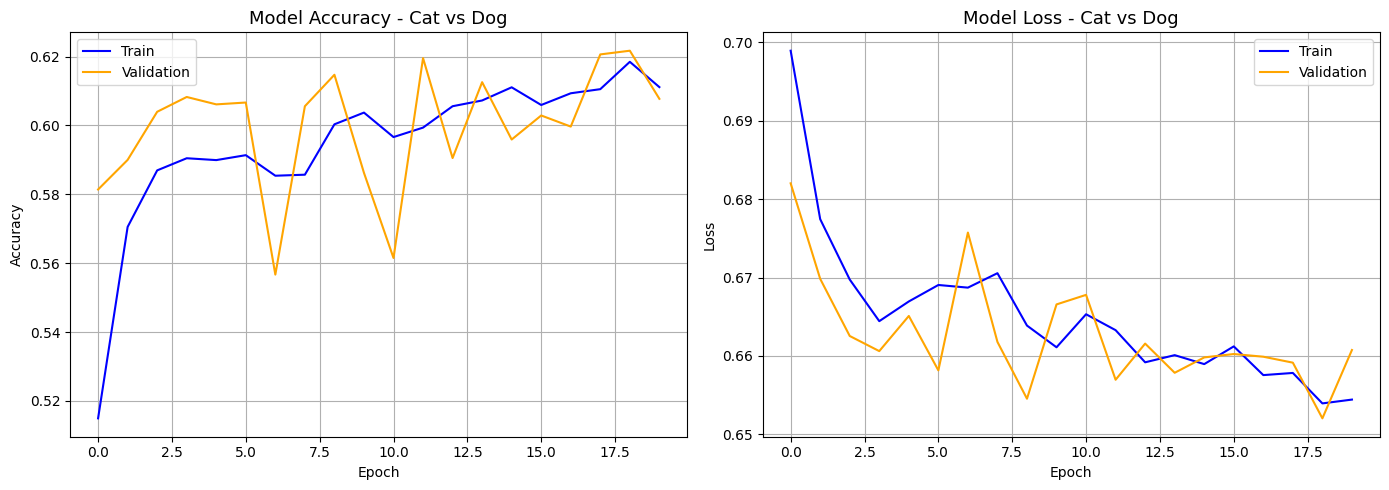

In [6]:
# ==============================================================
# BƯỚC 6: ĐÁNH GIÁ - BIỂU ĐỒ ACCURACY & LOSS
# ==============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(model_fit.history['accuracy'], label='Train', color='blue')
axes[0].plot(model_fit.history['val_accuracy'], label='Validation', color='orange')
axes[0].set_title('Model Accuracy - Cat vs Dog', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(model_fit.history['loss'], label='Train', color='blue')
axes[1].plot(model_fit.history['val_loss'], label='Validation', color='orange')
axes[1].set_title('Model Loss - Cat vs Dog', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

146/146 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step

=== Classification Report ===
              precision    recall  f1-score   support

         Cat       0.58      0.75      0.65      2280
         Dog       0.66      0.48      0.56      2372

    accuracy                           0.61      4652
   macro avg       0.62      0.62      0.61      4652
weighted avg       0.62      0.61      0.61      4652



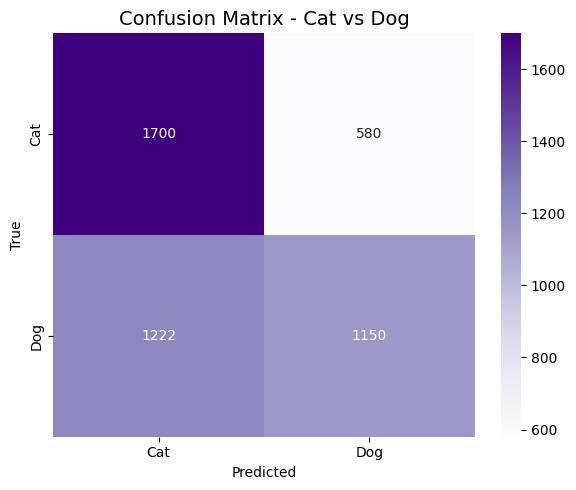


Test Accuracy: 0.6126 | Test Loss: 0.6574


In [7]:
# ==============================================================
# BƯỚC 7: CONFUSION MATRIX & CLASSIFICATION REPORT
# ==============================================================
y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()

print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Cat vs Dog', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f'\nTest Accuracy: {acc:.4f} | Test Loss: {loss:.4f}')